<a href="https://colab.research.google.com/github/Rayoyo/rare-neuro-mri/blob/main/01_resnet50_svm_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ResNet-50 Feature Extraction + SVM
*Created and runned with Google Colab*

This code has to be executed BEFORE all the other notebook, follow the numeration. \
**Dataset**: Rare Neurological Diseases MRI - curated ver, from [Kaggle](https://www.kaggle.com/datasets/ahsanneural/rare-neurological-diseases-mri-curated-edition) \
**Goal**: Establish baseline with classical feature extraction, using ResNet50 as a base


## **1) Drive mount & Kaggle dataset's download**


In order to correctly configure the project, in your drive there must be the folder for the project, in my case is inside the folder I use for my University projects.
Plus, to download the dataset directly from Kaggle (to have the last version), it is required to download your Kaggle's account info as follows:
- Go to [Kaggle' site](https://www.kaggle.com/) and log in it
- By intercat with your profile photo on the top-right, go to Settings
- Search for the section `API` and `Generate New Token`, it will open a pop up with some info:
  - **API TOKEN** (`KGAT_...`): This is your unique password. Copy it now, because Kaggle will never show it to you again

  - **Option 1** (`export KAGGLE_API_TOKEN=...`): It is used to save the token as a temporary environment variable in the terminalLinux/Mac.

  - **Option 2** (`mkdir -p ~/.kaggle && echo ...`): It is a terminal command that automatically creates the `~/.kaggle folder`, saves the token inside it in a file named access_token, and assigns the correct security permissions

  - **Final command** (kaggle competitions list): Example command to check if the token works.
- Copy the **API TOKEN** and return to Colab
- Open the menu on the left and intercat with the **key icon**
- Then add a **new secret**
  - **Name:** *KAGGLE_API_TOKEN*
  - **Value:** paste here the **API TOKEN**
- Finally, active the switch "Notebook access"

By following those steps, you will be able to download the dataset directly from the Kaggle's site.

In [1]:
import os
from pathlib import Path
from google.colab import drive, userdata
import sys

# 1. Google Drive mount
drive.mount('/content/drive')


# 2. Kaggle API configuration - AFTER adding the secret
try:
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    # If you don't use Colab's Secret, you can directly paste your token here (remove the comment)
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_..."


# 3. Path configuration
BASE_DIR = Path('/content/drive/MyDrive/University/rare-neuro-mri')
DATA_DIR = BASE_DIR / "data"                       # where to save dataset
MODEL_DIR = BASE_DIR / "restnet models"            # where to save the model
UTILS_DIR = BASE_DIR / "resnet utils"              # where to save useful files created during the analysis

# Create the base folder and the 'data' subfolder if they do not already exist
for d in [DATA_DIR, MODEL_DIR, UTILS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 4. Clone GitHub repo & add src folder to the project
REPO_URL = "https://github.com/Rayoyo/rare-neuro-mri.git"
REPO_DIR = Path("/content/rare-neuro-mri")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
print("Repo cloned!")

# repo added to importable moduls
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))


# 5. Kaggle's dataset
DATASET_SLUG = "ahsanneural/rare-neurological-diseases-mri-curated-edition"    #can be seen on Kaggle too when you want to download the file


# 6. Download verification and execution
# If the data folder is not empty, skip the download
if any(DATA_DIR.iterdir()):
    print(f" Dataset already present in: {DATA_DIR}")
    print("Folder contents:")
    for item in DATA_DIR.iterdir():
        print(f" - {item.name}")
else:
    print(f" Empty folder. Downloading the dataset '{DATASET_SLUG}'...")

    # Ensure that the Kaggle library is installed
    !pip install -q kaggle

    # Download and extract the data directly into the data folder on Drive
    !kaggle datasets download -d {DATASET_SLUG} -p "{DATA_DIR}" --unzip

    print(f"\n Download and extraction completed successfully!")
    print(f"The files are located in: {DATA_DIR}")


Mounted at /content/drive
Cloning into '/content/rare-neuro-mri'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 55 (delta 24), reused 35 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 1.98 MiB | 4.63 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Repo cloned!
 Dataset already present in: /content/drive/MyDrive/University/rare-neuro-mri/data
Folder contents:
 - rare_neuro_mri_curated


## **2) Install dependencies**

In [2]:
# install dependencies from requirements.txt or via pip
requirements_file = REPO_DIR / "requirements.txt"
if requirements_file.exists():
    !pip install -q -r {requirements_file}
    !pip install -q torchio
else:
    !pip install -q scikit-learn matplotlib seaborn tqdm
    !pip install -q torchio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 818.3 kB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 19.4 MB/s eta 0:00:00


In [ ]:
# ---------------------------------------------------------
# 1. Reproducibility & Device Setup
# ---------------------------------------------------------

In [3]:
import torch
# Select GPU if available, CPU if not
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


In [4]:
import sys

# Add the 'src' directory to sys.path directly to make modules within it importable
# REPO_DIR is expected to be available from a previous cell
src_dir_path = REPO_DIR / "src"
if str(src_dir_path) not in sys.path:
    sys.path.insert(0, str(src_dir_path))

# Import custom modules from the 'src' directory
# Now 'dataset', 'feature_extraction', 'metrics' are treated as top-level modules
from dataset import set_dataset_root, build_dataloaders, visualize_augmentations, set_seed
from feature_extraction import get_resnet50_extractor, extract_features, save_features
from metrics import evaluate_and_save_all

data structure & stat -- ignore

In [11]:
# 1. Dataset Preparation and Data Augmentation
actual_dataset_root = DATA_DIR / "rare_neuro_mri_curated"
set_dataset_root(actual_dataset_root)

train_ds, val_ds, test_ds = build_dataloaders(actual_dataset_root, batch_size=64, aug_factor=2)

Global dataset root set to: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated


In [ ]:
# 2. Feature Extraction with ResNet-50
resnet = get_resnet50_extractor(DEVICE)
X_train, y_train = extract_features(resnet, train_ds, DEVICE, desc="Train Features")
X_test, y_test = extract_features(resnet, test_ds, DEVICE, desc="Test Features")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 69.2MB/s]
Train Features:   0%|          | 0/44 [00:00<?, ?it/s]

In [ ]:
# 3. Classifier Training (SVM)
from sklearn.svm import SVC
clf = SVC(kernel='rbf', C=1.0)
clf.fit(X_train, y_train)

In [ ]:
# 4. Automatic Evaluation and Saving of Metrics and Graphs
y_pred = clf.predict(X_test)
class_names = list(train_ds.class_to_idx.keys())

evaluate_classification(
    y_true=y_test,
    y_pred=y_pred,
    class_names=class_names,
    save_dir=UTILS_DIR,
    model_name="resnet50_svm"
)

In [ ]:
# ---------------------------------------------------------
# 2. Data Structure Overview & Class Distribution
# ---------------------------------------------------------

In [5]:
DATASET_ROOT = DATA_DIR / "rare_neuro_mri_curated"

# Explore structure overview & stats
for root, dirs, files in os.walk(DATASET_ROOT):
    level = root.replace(str(DATASET_ROOT), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    if level < 3 and files:
        for f in files[:3]:
            print(f'{subindent}{f} ...')
        if len(files) > 3:
            print(f'{subindent}... and {len(files)-3} more files')

rare_neuro_mri_curated/
  disease_summary.csv ...
  metadata.csv ...
  test/
    fukuyama_muscular_dystrophy/
      fukuyama_muscular_dystrophy_test_0000.jpg ...
      fukuyama_muscular_dystrophy_test_0001.jpg ...
      fukuyama_muscular_dystrophy_test_0002.jpg ...
      ... and 57 more files
    hallervorden_spatz_disease/
      hallervorden_spatz_disease_test_0000.jpg ...
      hallervorden_spatz_disease_test_0001.jpg ...
      hallervorden_spatz_disease_test_0002.jpg ...
      ... and 57 more files
    moyamoya_disease/
      moyamoya_disease_test_0000.jpg ...
      moyamoya_disease_test_0001.jpg ...
      moyamoya_disease_test_0002.jpg ...
      ... and 57 more files
    pachygyria_cerebellar_hypoplasia/
      pachygyria_cerebellar_hypoplasia_test_0000.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0001.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0002.jpg ...
      ... and 57 more files
    walker_warburg_syndrome/
      walker_warburg_syndrome_test_0000.jpg ...
      

class distribution -- conferma le info su kaggle

In [6]:
import pandas as pd
import os

splits = ['train', 'val', 'test']
disease_classes = []
split_stats = {}

for split in splits:
    split_path = DATASET_ROOT / split
    if not split_path.exists():
        continue

    classes = sorted([d for d in os.listdir(split_path) if (split_path / d).is_dir()])
    disease_classes = classes
    split_stats[split] = {}

    for cls in classes:
        cls_path = split_path / cls
        n_images = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        split_stats[split][cls] = n_images

df_stats = pd.DataFrame(split_stats).fillna(0).astype(int)
print("\nDataset Statistics:")
print(df_stats)
print(f"Total images: {df_stats.sum().sum()}")
print(f"Classes: {disease_classes}")


Dataset Statistics:
                                  train  val  test
fukuyama_muscular_dystrophy         280   60    60
hallervorden_spatz_disease          280   60    60
moyamoya_disease                    280   60    60
pachygyria_cerebellar_hypoplasia    280   60    60
walker_warburg_syndrome             280   60    60
Total images: 2000
Classes: ['fukuyama_muscular_dystrophy', 'hallervorden_spatz_disease', 'moyamoya_disease', 'pachygyria_cerebellar_hypoplasia', 'walker_warburg_syndrome']


Sample Grid Visualization - to check

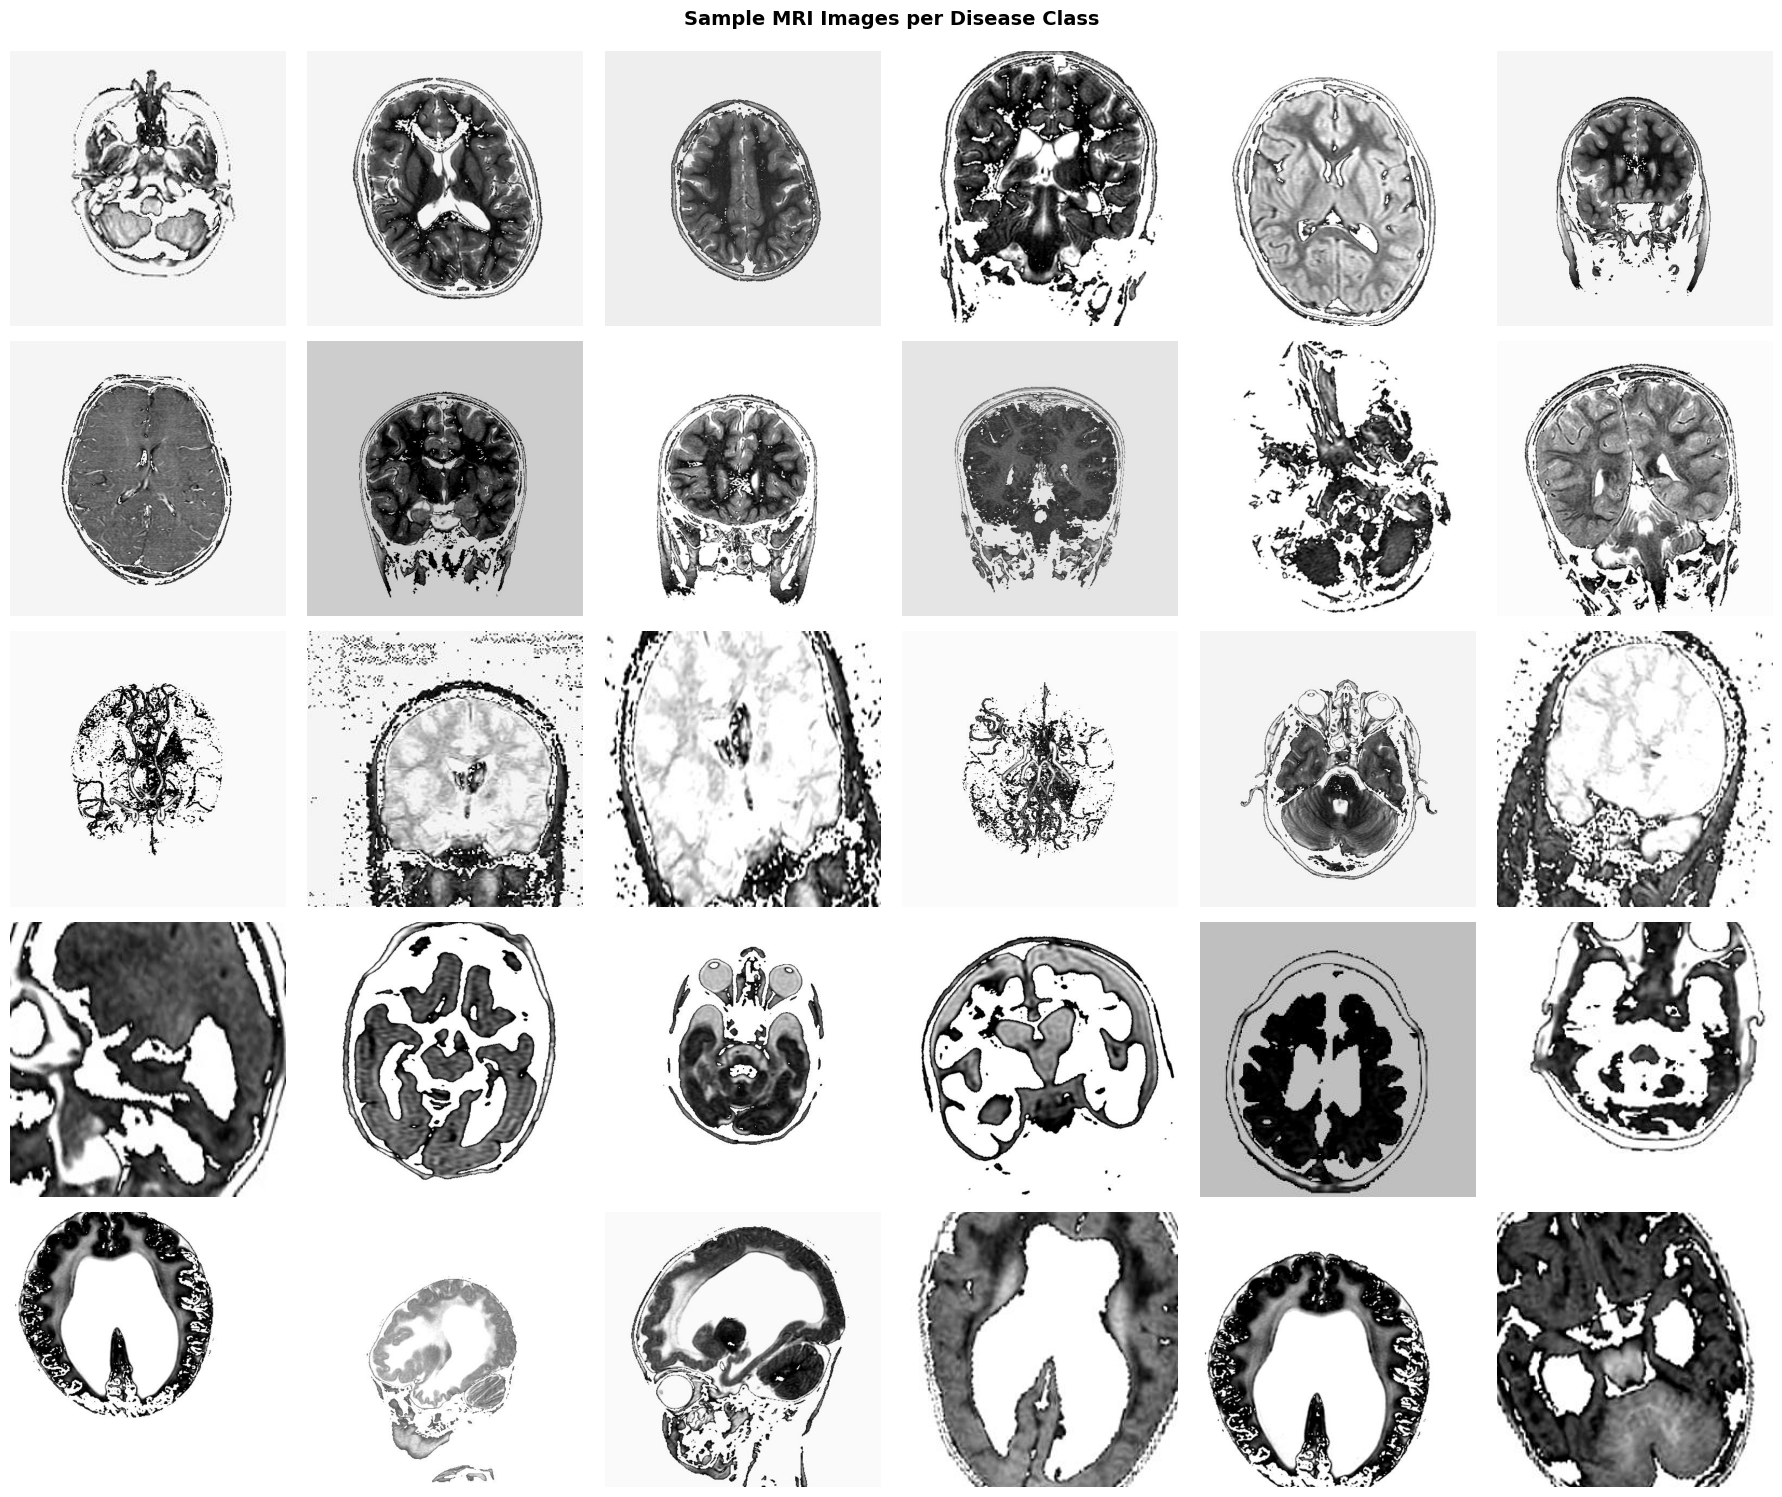

In [7]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

def show_samples(n_per_class=4):
    fig, axes = plt.subplots(len(disease_classes), n_per_class,
                             figsize=(n_per_class*3, len(disease_classes)*3))
    train_path = os.path.join(DATASET_ROOT, 'train')

    for i, cls in enumerate(disease_classes):
        cls_path = os.path.join(train_path, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        sampled = random.sample(images, min(n_per_class, len(images)))
        for j, img_name in enumerate(sampled):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            axes[i, j].imshow(img, cmap='gray' if img.mode == 'L' else None)
            axes[i, j].axis('off')
            if j == 0:
                axes[i, j].set_ylabel(cls, fontsize=10, fontweight='bold',
                                      rotation=0, ha='right', va='center')

    plt.suptitle('Sample MRI Images per Disease Class', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(UTILS_DIR / "sample_grid.png", dpi=150, bbox_inches='tight')
    plt.show()

show_samples(6)

**Define Transforms & Dataset**  -- DA TENERE

This part is common on the two notebook of the models used.
Here are done some things:
- Set the global seed used in the notebook
- Initialization of the dataset in order to use the data augmentation only during the training
- Are shown some random samples of the transformation odne
- The standard PyTorch data loaders is initialized



In [8]:

from torch.utils.data import DataLoader

In [10]:
# 1. global seed on notebook
SEED = 33
set_seed(SEED)

set_dataset_root(DATASET_ROOT)

Global dataset root set to: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated


In [11]:
# 2. Dataset initialization (Data Augmentation active only on train)

train_ds, val_ds, test_ds = build_dataloaders(
    dataset_root=DATASET_ROOT,
    batch_size=32,
    img_size=224,
    aug_factor=2,  # Double the on-the-fly generated training samples per epoch
    seed=SEED
)

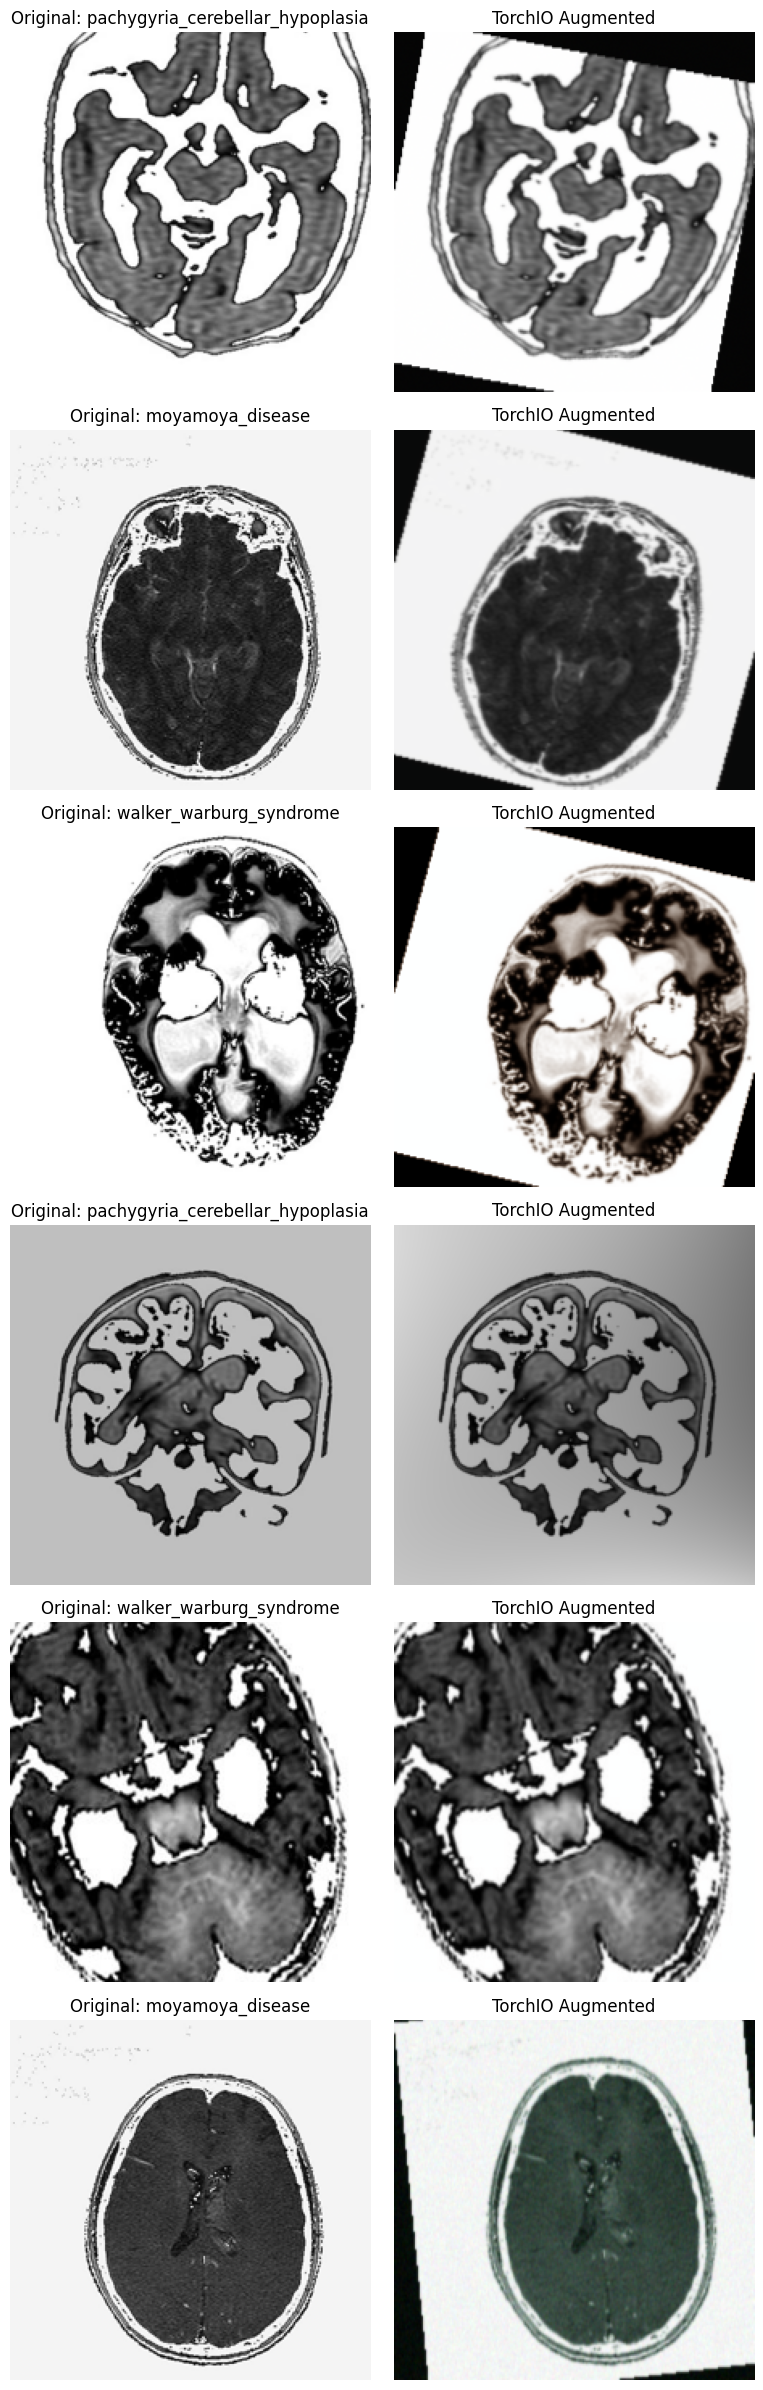

In [12]:
# 3. View some random examples to verify the quality of the transformations
visualize_augmentations(train_ds, num_samples=6, seed=SEED)

In [13]:
# 4. Initialize the standard PyTorch DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

Load ResNet-50 Feature Extractor

In [ ]:
# ---------------------------------------------------------
# 6. Load Model & Feature Extraction
# ---------------------------------------------------------

In [15]:
import torch
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report

# import custom moduls
#from dataset import build_dataloaders, set_seed
#from feature_extraction import get_resnet50_extractor, extract_features, save_features

# configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 33
set_seed(SEED)

# load dataset (Augmentation active on train)
train_ds, val_ds, test_ds = build_dataloaders(DATASET_ROOT, batch_size=64, aug_factor=2, seed=SEED)
disease_classes = list(train_ds.class_to_idx.keys())

# ResNet-50 extractor
extractor = get_resnet50_extractor(DEVICE)

# feature extraction
X_train, y_train = extract_features(extractor, train_ds, DEVICE, desc="Extracting Train Features")
X_val, y_val = extract_features(extractor, val_ds, DEVICE, desc="Extracting Val Features")
X_test, y_test = extract_features(extractor, test_ds, DEVICE, desc="Extracting Test Features")

# feature saving
features_dict = {
    "X_train.npy": X_train, "y_train.npy": y_train,
    "X_val.npy": X_val,     "y_val.npy": y_val,
    "X_test.npy": X_test,   "y_test.npy": y_test,
}
save_features(MODEL_DIR, features_dict)
print(f"\n All features have been successfully saved in: {MODEL_DIR}")

Extracting Test Features: 100%|██████████| 5/5 [02:57<00:00, 35.43s/it]


✅ All features have been saved in: /content/drive/MyDrive/University/rare-neuro-mri/restnet models

 All features have been successfully saved in: /content/drive/MyDrive/University/rare-neuro-mri/restnet models


**PCA Visualization**

PCA projects the multidimensional space ($2048$ dimensions) onto $2$ dimensions to assess the separability of the $5$ neurological conditions

/tmp/ipykernel_2094/1715474084.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(class_names))


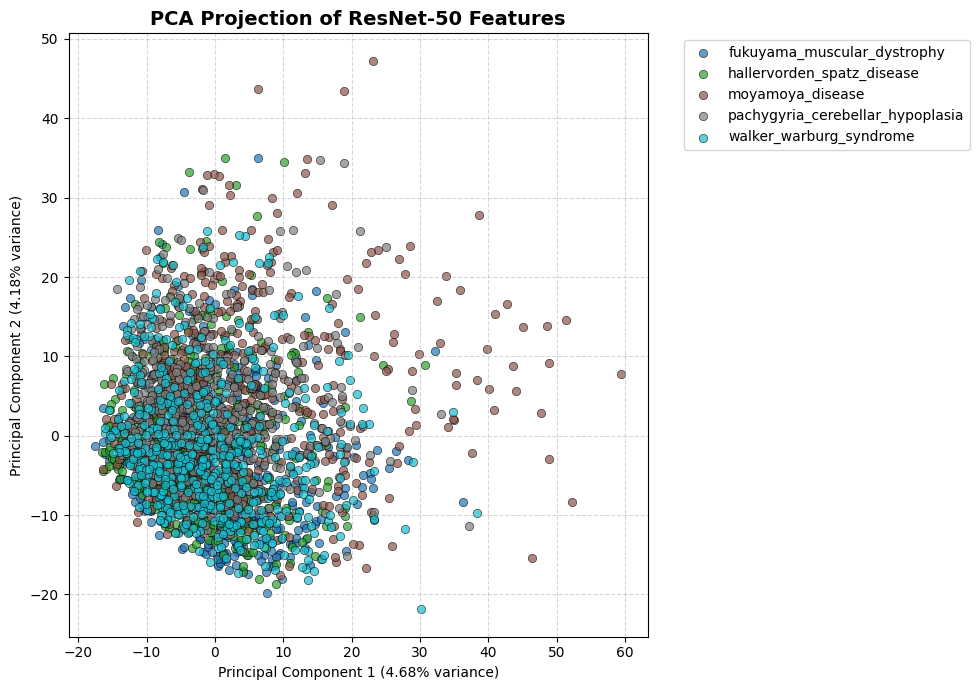

In [16]:
def plot_pca_features(X, y, class_names, title="PCA Projection of ResNet-50 Features"):
    # Pre-normalization (fundamental for PCA)
    X_scaled = StandardScaler().fit_transform(X)

    # Reduction to 2 principal components
    pca = PCA(n_components=2, random_state=SEED)
    X_pca = pca.fit_transform(X_scaled)

    var_exp = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(10, 7))
    colors = plt.cm.get_cmap("tab10", len(class_names))

    for i, cls in enumerate(class_names):
        mask = (y == i)
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=cls,
            alpha=0.7,
            edgecolors='k',
            linewidths=0.5,
            c=[colors(i)]
        )

    plt.xlabel(f"Principal Component 1 ({var_exp[0]:.2f}% variance)")
    plt.ylabel(f"Principal Component 2 ({var_exp[1]:.2f}% variance)")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Perform PCA visualization on the training set
plot_pca_features(X_train, y_train, disease_classes)

SVM Hyperparameter Tuning

In [17]:
# Standardization (StandardScaler fit on Train, transform on Val)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

C_values = [0.01, 0.1, 1, 10, 100]
best_C = None
best_val_f1 = 0

print("Hyperparameter tuning (Linear SVM)...")
for C in C_values:
    svm = SVC(kernel='linear', C=C, random_state=SEED)
    svm.fit(X_train_s, y_train)
    val_preds = svm.predict(X_val_s)

    val_f1 = f1_score(y_val, val_preds, average='macro')
    val_acc = accuracy_score(y_val, val_preds)

    print(f"  C={C:>6.2f} | Val Acc: {val_acc:.4f} | Val Macro-F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_C = C

print(f"\nBest C: {best_C} (Val Macro-F1: {best_val_f1:.4f})")

Hyperparameter tuning (Linear SVM)...
  C=  0.01 | Val Acc: 0.9933 | Val Macro-F1: 0.9933
  C=  0.10 | Val Acc: 0.9933 | Val Macro-F1: 0.9933
  C=  1.00 | Val Acc: 0.9933 | Val Macro-F1: 0.9933
  C= 10.00 | Val Acc: 0.9933 | Val Macro-F1: 0.9933
  C=100.00 | Val Acc: 0.9933 | Val Macro-F1: 0.9933

Best C: 0.01 (Val Macro-F1: 0.9933)


Final SVM Training & Test Evaluation  -- try

In [18]:
# Combining training and validation sets for final retraining
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])

# Scaler fit on the combined Train+Val dataset
scaler_final = StandardScaler()
X_tv_s = scaler_final.fit_transform(X_tv)
X_test_s = scaler_final.transform(X_test)

# Final SVM training with the best C found
final_svm = SVC(kernel='linear', C=best_C, probability=True, random_state=SEED)
final_svm.fit(X_tv_s, y_tv)

# Prediction on Test Set
test_preds = final_svm.predict(X_test_s)
test_proba = final_svm.predict_proba(X_test_s)

test_acc = accuracy_score(y_test, test_preds)
test_macro_f1 = f1_score(y_test, test_preds, average='macro')

print("=" * 60)
print("RESNET-50 + SVM — FINAL TEST RESULTS")
print("=" * 60)
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Test Macro-F1:     {test_macro_f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, test_preds, target_names=disease_classes, digits=4))

RESNET-50 + SVM — FINAL TEST RESULTS
Test Accuracy:     0.9800
Test Macro-F1:     0.9799

Detailed Report:
                                  precision    recall  f1-score   support

     fukuyama_muscular_dystrophy     0.9831    0.9667    0.9748        60
      hallervorden_spatz_disease     0.9828    0.9500    0.9661        60
                moyamoya_disease     0.9677    1.0000    0.9836        60
pachygyria_cerebellar_hypoplasia     1.0000    1.0000    1.0000        60
         walker_warburg_syndrome     0.9672    0.9833    0.9752        60

                        accuracy                         0.9800       300
                       macro avg     0.9802    0.9800    0.9799       300
                    weighted avg     0.9802    0.9800    0.9799       300



 EVALUATION RESULTS: RESNET50_SVM
Test Accuracy:     0.9800
Test Macro-F1:     0.9799
Test Weighted-F1:  0.9799

Detailed Classification Report:
                                  precision    recall  f1-score   support

     fukuyama_muscular_dystrophy     0.9831    0.9667    0.9748        60
      hallervorden_spatz_disease     0.9828    0.9500    0.9661        60
                moyamoya_disease     0.9677    1.0000    0.9836        60
pachygyria_cerebellar_hypoplasia     1.0000    1.0000    1.0000        60
         walker_warburg_syndrome     0.9672    0.9833    0.9752        60

                        accuracy                         0.9800       300
                       macro avg     0.9802    0.9800    0.9799       300
                    weighted avg     0.9802    0.9800    0.9799       300



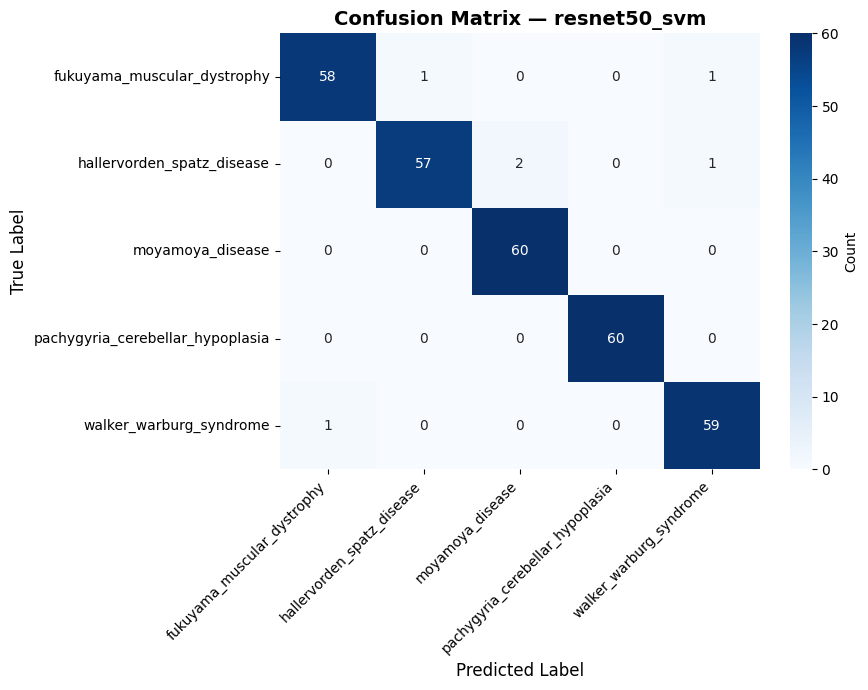

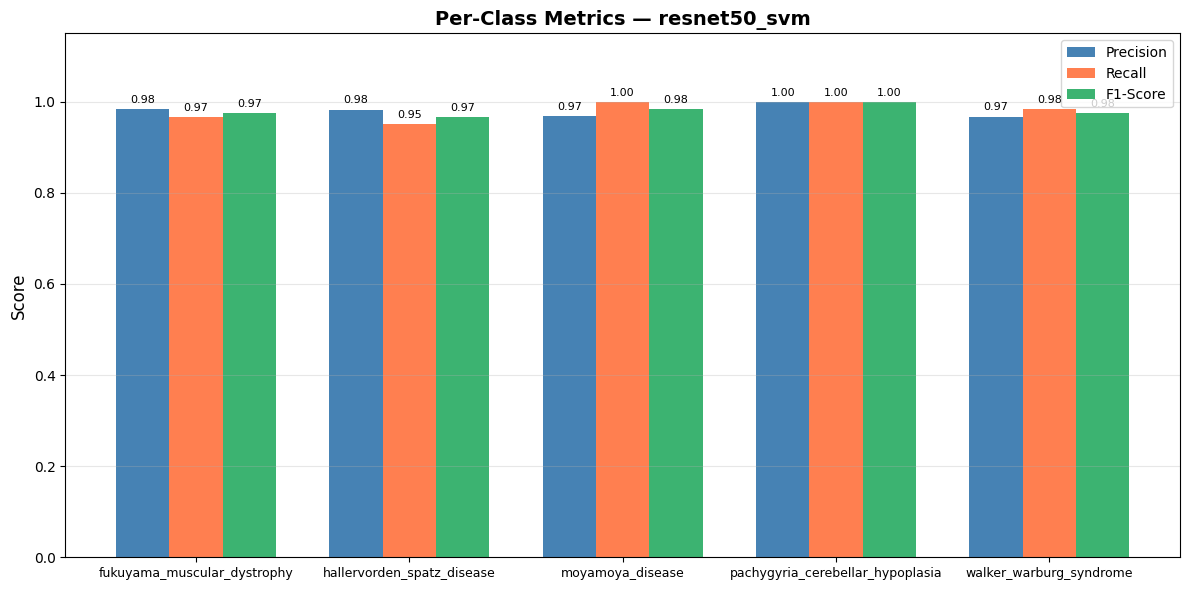


Running few-shot experiments...


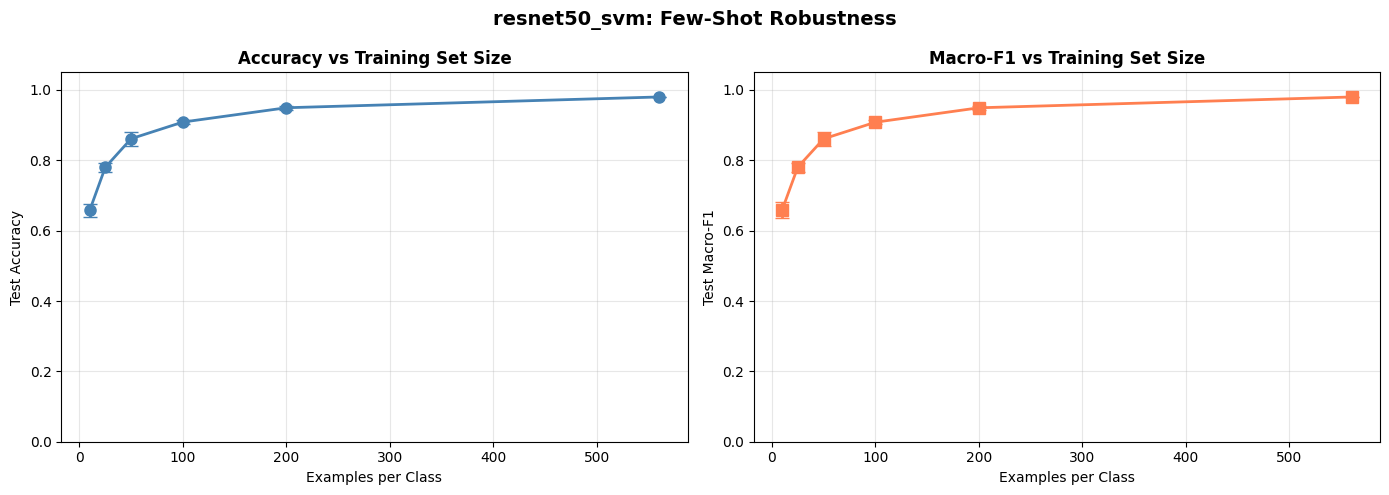

 n_per_class  acc_mean  acc_std  f1_mean   f1_std
          10  0.658000 0.017839 0.659640 0.023095
          25  0.780000 0.012472 0.780403 0.012458
          50  0.861333 0.019505 0.861050 0.020481
         100  0.908667 0.005416 0.908209 0.004948
         200  0.949333 0.005735 0.949204 0.005638
         560  0.980000 0.000000 0.979941 0.000000

 Output salvati con successo:
  - Grafici salvati in: /content/drive/MyDrive/University/rare-neuro-mri/resnet utils
  - Artifacts e Pesi salvati in: /content/drive/MyDrive/University/rare-neuro-mri/restnet models


In [20]:
from pathlib import Path
from metrics import evaluate_and_save_all

# Artifacts to pack
artifacts = {
    'svm': final_svm,
    'scaler': scaler_final,
    'class_names': disease_classes,
    'class_to_idx': train_ds.class_to_idx,
    'best_C': best_C
}

# Full execution of evaluation, plotting, few-shot, and saving
evaluate_and_save_all(
    y_true=y_test,
    y_pred=test_preds,
    class_names=disease_classes,
    utils_dir=UTILS_DIR,
    model_dir=MODEL_DIR,
    model_name="resnet50_svm",
    X_train_feats=X_train,
    y_train_labels=y_train,
    X_test_feats=X_test,
    artifacts_to_save=artifacts,
    torch_model_to_save=extractor,  # save backbone ResNet-50
    seed=SEED
)